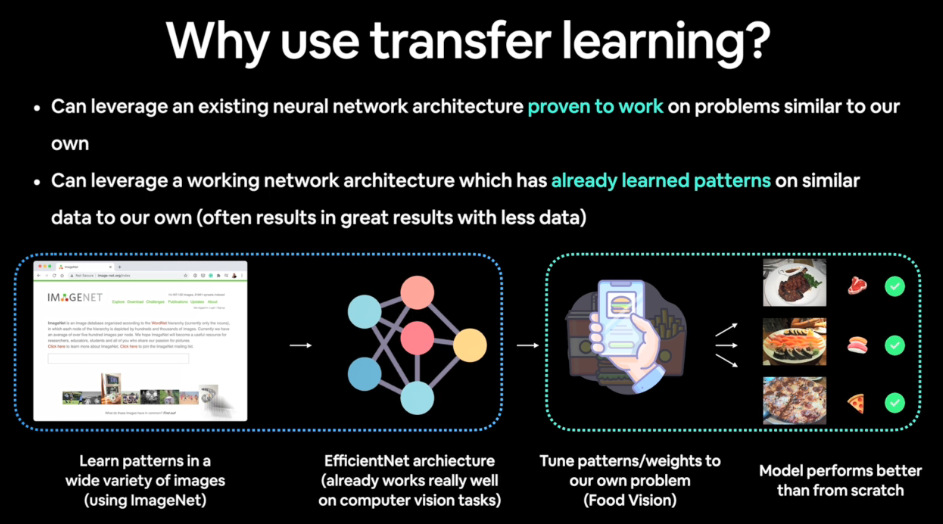

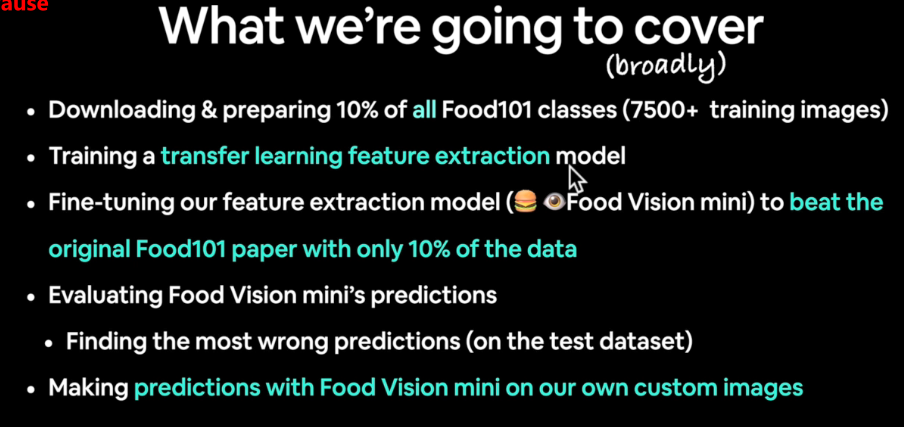

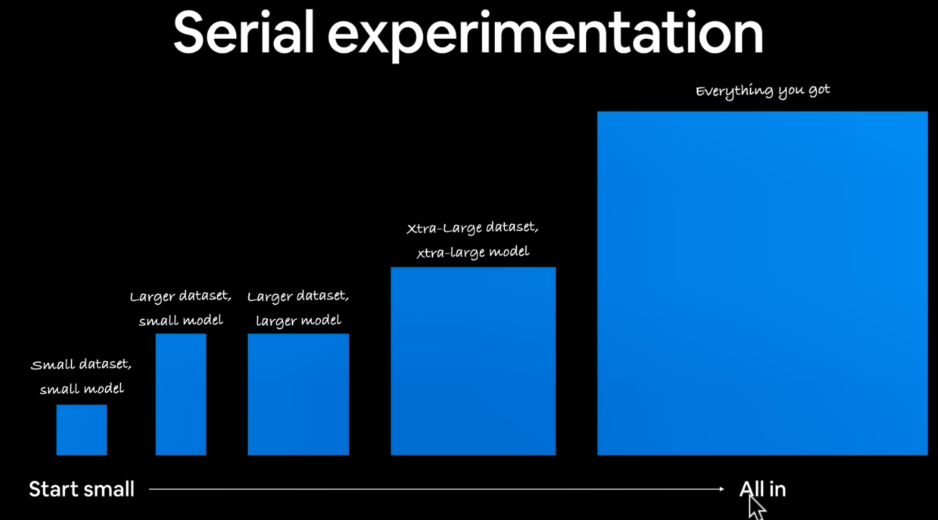

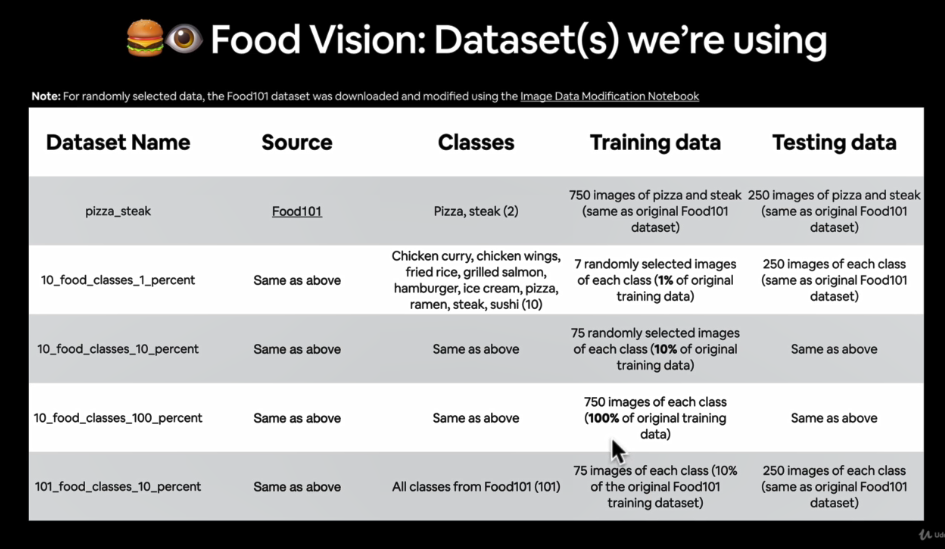

<h1 style="color:red">lec 002:-Getting helper functions ready and downloading data to model.mp4</h1>

# Transfer Learning with TensorFlow Part 3: Scaling up (🍔👁 Food Vision mini)

We've seen the power of transfer learning feature extraction and fine-tuning, now it's time to scale up to all of the classes in Food101 (101 total classes of food).

Our goal is to beat the original Food101 paper with 10% of the training (leveraging the power of deep learning).

Original Food101 paper: https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/

Our baseline to beat is 50.76% accuracy accross 101 classes.

In [ ]:
# Check to see if we're using a GPU
!nvidia-smi

## Creating helper functions

In previous notebook, we've created a series of helper functions to different tasks, let's download them

In [1]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-03-11 08:36:51--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-03-11 08:36:51 (88.2 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [2]:
# Import series of helper functions for our notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir

## 101 Food Classes: working with less data

Our goal is to beat the original Food101 paper with 10% of the training data, so let's download it.

The data we're downloading comes from the original Food101 dataset but has been preprocessed using the image_data_modification notebook - https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/image_data_modification.ipynb

In [3]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
unzip_data("101_food_classes_10_percent.zip")

train_dir = "101_food_classes_10_percent/train"
test_dir = "101_food_classes_10_percent/test"

--2026-03-11 08:37:16--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 192.178.142.207, 142.251.121.207, 142.251.108.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|192.178.142.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1625420029 (1.5G) [application/zip]
Saving to: ‘101_food_classes_10_percent.zip’

101_food_classes_10 100%[===================>]   1.51G   184MB/s    in 10s     

2026-03-11 08:37:26 (151 MB/s) - ‘101_food_classes_10_percent.zip’ saved [1625420029/1625420029]



In [ ]:
# How many images/classes are there?
walk_through_dir("101_food_classes_10_percent")

In [4]:
# Setup data inputs
import tensorflow as tf
IMG_SIZE = (224,224)
train_data_all_10_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                                label_mode="categorical",
                                                                                image_size=IMG_SIZE)
test_data_all = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                    label_mode="categorical",
                                                                    image_size=IMG_SIZE,
                                                                    shuffle=False) # don't shuffle test data for prediction analysis

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


<h1 style="color:red">lec 003:-Outlining the model we're going to build and building a ModelCheckpoint callback.mp4</h1>

## Train a big dog model with transfer learning on 10% of 101 food classes

Here are the steps we're going to take:
* Create a ModelCheckpoint callback
* Create a data augmentation layer to build data augmentation right into the model
* Build a headless(no top layers) Functional EfficientNetB0 backboned-model (we'll create our own output layer)
* Compile our model
* Feature extract for 5 full passes (5 epochs on the train datset and validation on 15% of the test data, to save epoch time)

In [15]:
# Create checkpoint callback
checkpoint_path = "101_classes_10_percent_data_model_checkpoint.weights.h5"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                         save_weights_only=True,
                                                         monitor="val_accuracy",
                                                         save_best_only = True)

<h1 style="color:red">lec 004:-Creating a data augmentation layer to use with our model.mp4</h1>

In [ ]:
# Create data augmentation layer to incorporate it right into the model
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

# Setup data augmentation
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
    layers.RandomZoom(0.2),
    # layers.Rescaling(1/255.) # rescale inputs of images to between 0 & 1, required for model like Resnet50
],name="data_augmentation")

<h1 style="color:red">lec 005:-Creating a headless EfficientNetB0 model with data augmentation built in.mp4</h1>

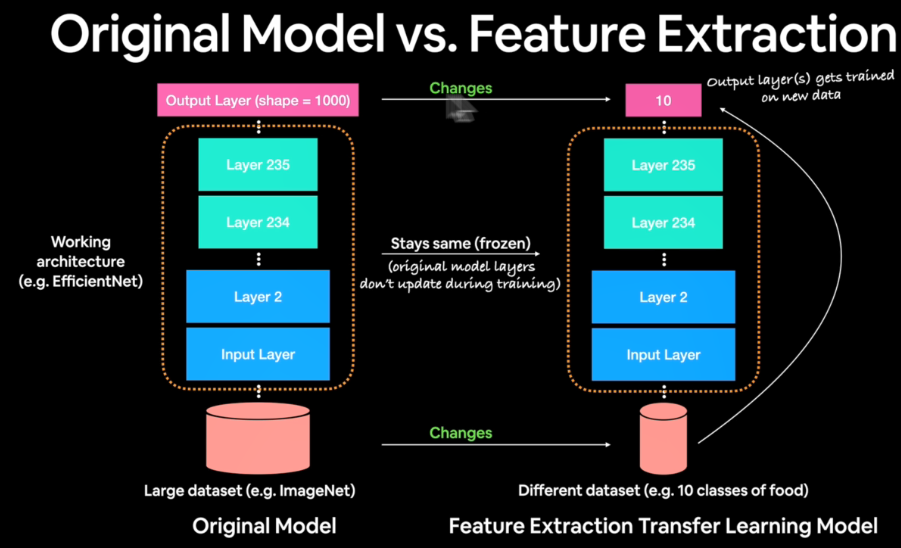

In [ ]:
# Setup the base model and freeze its layers (this will extract features)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

# Setup the model architecture with trainable top layers
inputs = layers.Input(shape=(224,224,3),name="input_layer")
x = data_augmentation(inputs) # augment images (only happen during training phase)
x = base_model(x,training=False) # put the base model in inference mode so weights which need to stay frozen, stay frozen
x = layers.GlobalAveragePooling2D(name="global_avg_pool_layer")(x)
outputs = layers.Dense(len(train_data_all_10_percent.class_names),activation="softmax",name="output_layer")(x)
model = tf.keras.Model(inputs,outputs)

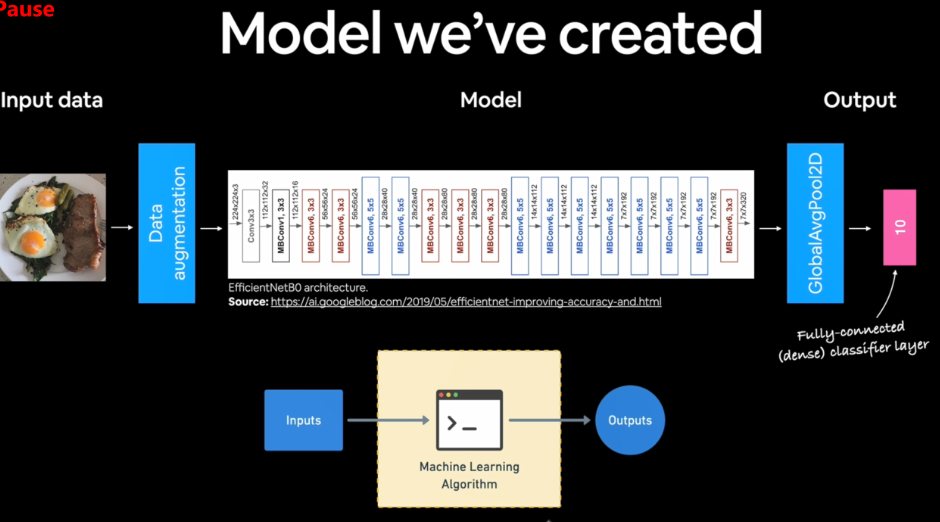

In [ ]:
# Get a summary of a model we've created
model.summary()

<h1 style="color:red">lec 006:-Fitting and evaluating our biggest transfer learning model yet.mp4</h1>

In [11]:
# Compile
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit
history_all_classes_10_percent = model.fit(train_data_all_10_percent,
                                           epochs =5,
                                           validation_data =test_data_all,
                                           validation_steps= int(0.15*len(test_data_all)),
                                           callbacks=[checkpoint_callback])

Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 56s 175ms/step - accuracy: 0.1590 - loss: 3.9724 - val_accuracy: 0.4600 - val_loss: 2.5384
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 39s 163ms/step - accuracy: 0.4741 - loss: 2.3252 - val_accuracy: 0.5106 - val_loss: 2.0941
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 41s 174ms/step - accuracy: 0.5579 - loss: 1.8913 - val_accuracy: 0.5238 - val_loss: 1.9396
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 38s 162ms/step - accuracy: 0.5894 - loss: 1.6745 - val_accuracy: 0.5432 - val_loss: 1.8174
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 155ms/step - accuracy: 0.6288 - loss: 1.5105 - val_accuracy: 0.5408 - val_loss: 1.7886


In [ ]:
# Evaluate on the whole test dataset
feature_extraction_results = model.evaluate(test_data_all)
feature_extraction_results

# feature_extraction_results = [1.5949325561523438, 0.5814653635025024]

142/790 ━━━━━━━━━━━━━━━━━━━━ 54s 84ms/step - accuracy: 0.4819 - loss: 2.0389

In [ ]:
# plot_loss_curves(history_all_classes_10_percent)

> 🤔 **Question:** What do these curves suggest? Hint: ideally, the two curves should be very similar to each other, if not it may suggest that our model is overfitting (performing too well on the training data and not generalizing to unseen data).

<br>
<hr>
If your **training accuracy vs. epoch** and **validation accuracy vs. epoch** curves intersect in the middle, it suggests a shift in generalization behavior during training.

Interpretation:

1. **Early phase**
   Validation accuracy may be higher than training accuracy.
   This is normal when:

   * Dropout is active during training but not validation.
   * Data augmentation makes training harder.
   * Batch normalization behaves differently during training.

2. **Intersection point**
   The point where training accuracy surpasses validation accuracy often marks the beginning of **overfitting**.

3. **After intersection**
   If training accuracy keeps increasing while validation accuracy plateaus or decreases, the model is memorizing training data instead of learning generalizable patterns.

What it suggests overall:

* If both curves rise together and stay close → good generalization.
* If they cross and then diverge significantly → overfitting begins at the crossing epoch.
* If they fluctuate around each other but remain close → training is stable.

Key rule:
Ideally, validation accuracy should track training accuracy closely with a small gap. A growing gap after intersection indicates overfitting.


<h1 style="color:red">lec 007:-Unfreezing some layers in our base model to prepare for fine-tuning.mp4</h1>

## Fine-tuning

In [ ]:
# Unfreeze all of the layers in base model
base_model.trainable = True

# Refreeze every layer except the last 5
for layer in base_model.layers[:-5]:
  layer.trainable = False

In [ ]:
# Recompile model with lower learning (it's typically best practice to lower the learning rate when fine-tuning)
model.compile(loss="categorical_crossentropy",
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001), # learning rate lowered by 10x
              metrics=["accuracy"])

In [ ]:
# What layers in the model are trainable?
for layer in model.layers:
  print(layer.name,layer.trainable)

In [ ]:
# Check which layers are trainable in our base model
for layer_number, layer in enumerate(model.layers[2].layers):
  print(layer_number, layer.name, layer.trainable)

<h1 style="color:red">lec 008:-Fine-tuning our feature extraction model and evaluating its performance.mp4</h1>

In [ ]:
# Fine-tune for 5 more epochs
fine_tune_epochs = 10 # model has already done 5 epochs (feature extraction), this the total number of epochs we're after (5+5=10)

# Fine-tune our model
history_all_classes_10_percent_fine_tune = model.fit(train_data_all_10_percent,
                                                     epochs=fine_tune_epochs,
                                                     validation_data = test_data_all,
                                                     validation_steps = int(0.15*len(test_data_all)),
                                                     initial_epoch = history_all_classes_10_percent.epoch[-1])

In [ ]:
# Evaluate on the whole test data
all_classes_10_percent_fine_tune_results = model.evaluate(test_data_all)
all_classes_10_percent_fine_tune_results

In [ ]:
# Compare the histories of feature extraction model with fine-tuning model
compare_historys(original_history=history_all_classes_10_percent,
                 new_history = history_all_classes_10_percent_fine_tune,
                 initial_epochs=5)

<h1 style="color:red">lec 009:-Saving and loading our trained model.mp4</h1>

## Saving and loading our model

To use our model in an external application, we'll need to save it and export it somewhere.

In [ ]:
# Save our fine-tuning model
model.save("drive/MyDrive/tensorflow_course/101_food_classes_10_percent_saved_big_dog_model.keras")

In [ ]:
# Load an evaluate saved model
loaded_model = tf.keras.models.load_model("drive/MyDrive/tensorflow_course/101_food_classes_10_percent_saved_big_dog_model.keras")

In [ ]:
# Evaluated loaded model and compare performance to pre-saved model
loaded_model_results = loaded_model.evaluate(test_data_all)
loaded_model_results

In [ ]:
# The results from our loaded_model (above) should be very similar to the results below
all_classes_10_percent_fine_tune_results

<h1 style="color:red">lec 010:-Downloading a pretrained model to make and evaluate predictions with.mp4</h1>

## Evaluating the performance of the big dog model across all different classes

Let's make some predictions, visualize them and then later find out which predictions were the "most" wrong.

In [4]:
# tecaher's model
import tensorflow as tf

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/06_101_food_class_10_percent_saved_big_dog_model.zip

--2026-03-10 04:51:33--  https://storage.googleapis.com/ztm_tf_course/food_vision/06_101_food_class_10_percent_saved_big_dog_model.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.188.207, 74.125.142.207, 74.125.195.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.188.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46760742 (45M) [application/zip]
Saving to: ‘06_101_food_class_10_percent_saved_big_dog_model.zip’

06_101_food_class_1 100%[===================>]  44.59M   135MB/s    in 0.3s    

2026-03-10 04:51:34 (135 MB/s) - ‘06_101_food_class_10_percent_saved_big_dog_model.zip’ saved [46760742/46760742]



In [6]:
unzip_data("/content/06_101_food_class_10_percent_saved_big_dog_model.zip")

TFSMLayer is only a layer, not a full Keras model, so it does not have .summary().

Wrap the layer inside a model first.

Create a model wrapper.

In [54]:
import tensorflow as tf
import keras

teacher_layer = keras.layers.TFSMLayer(
    "/content/06_101_food_class_10_percent_saved_big_dog_model",
    call_endpoint="serving_default"
)

inputs = tf.keras.Input(shape=(224,224,3))
outputs = teacher_layer(inputs)

teacher_model = tf.keras.Model(inputs, outputs)

In [55]:
teacher_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tfsm_layer_1 (TFSMLayer)        │ (None, 101)            │     4,178,951 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,951 (15.94 MB)

 Trainable params: 4,136,929 (15.78 MB)

 Non-trainable params: 42,022 (164.15 KB)

In [5]:
# downloading our model from google drive
!wget "https://drive.google.com/uc?export=download&id=1M-pIQCW6v6aYAKkfLs3RWXUkcrr7cOEI"

--2026-03-11 08:37:46--  https://drive.google.com/uc?export=download&id=1M-pIQCW6v6aYAKkfLs3RWXUkcrr7cOEI
Resolving drive.google.com (drive.google.com)... 142.251.121.100, 142.251.121.101, 142.251.121.138, ...
Connecting to drive.google.com (drive.google.com)|142.251.121.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1M-pIQCW6v6aYAKkfLs3RWXUkcrr7cOEI&export=download [following]
--2026-03-11 08:37:46--  https://drive.usercontent.google.com/download?id=1M-pIQCW6v6aYAKkfLs3RWXUkcrr7cOEI&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.108.132, 2607:f8b0:4023:807::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.108.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24867572 (24M) [application/octet-stream]
Saving to: ‘uc?export=download&id=1M-pIQCW6v6aYAKkfLs3RWXUkcrr7cOEI’

uc?export=downloa

In [6]:
!ls -lh /content

total 1.6G
drwxr-xr-x 4 root root 4.0K Mar 11 08:37  101_food_classes_10_percent
-rw-r--r-- 1 root root 1.6G Feb 23  2021  101_food_classes_10_percent.zip
drwx------ 5 root root 4.0K Mar 11 08:36  drive
-rw-r--r-- 1 root root  11K Mar 11 08:36  helper_functions.py
drwxr-xr-x 3 root root 4.0K Mar 11 08:37  __MACOSX
drwxr-xr-x 2 root root 4.0K Mar 11 08:36  __pycache__
drwxr-xr-x 1 root root 4.0K Jan 16 14:24  sample_data
-rw-r--r-- 1 root root  24M Feb 24 17:50 'uc?export=download&id=1M-pIQCW6v6aYAKkfLs3RWXUkcrr7cOEI'


In [7]:
!file "/content/uc?export=download&id=1M-pIQCW6v6aYAKkfLs3RWXUkcrr7cOEI"

/content/uc?export=download&id=1M-pIQCW6v6aYAKkfLs3RWXUkcrr7cOEI: Zip archive data, at least v2.0 to extract, compression method=store


In [8]:
!mv "/content/uc?export=download&id=1M-pIQCW6v6aYAKkfLs3RWXUkcrr7cOEI" /content/model.zip

In [9]:
!unzip /content/model.zip -d /content/model

Archive:  /content/model.zip
 extracting: /content/model/metadata.json  
 extracting: /content/model/config.json  
 extracting: /content/model/model.weights.h5  


In [10]:
# laoding our keras format model
import keras

loaded_model = keras.models.load_model("/content/model")
loaded_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool_layer           │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,596 (22.89 MB)

 Trainable params: 910,821 (3.47 MB)

 Non-trainable params: 3,268,131 (12.47 MB)

 Optimizer params: 1,821,644 (6.95 MB)

In [11]:
# Evaluate the loaded model (the one we just downloaded on test data)
results_downloaded_model = loaded_model.evaluate(test_data_all)
results_downloaded_model

790/790 ━━━━━━━━━━━━━━━━━━━━ 73s 82ms/step - accuracy: 0.5977 - loss: 1.5154


[1.422608494758606, 0.6186930537223816]

<h1 style="color:red">lec 011:-Making predictions with our trained model on 25,250 test samples</h1>

## Making predictions with our trained model

In [ ]:
# Make predictions with model
pred_probs = loaded_model.predict(test_data_all,verbose=1) # set verbosity to see how long is keft

790/790 ━━━━━━━━━━━━━━━━━━━━ 2389s 3s/step


In [13]:
len(test_data_all)

790

In [14]:
790 * 32 # one batch of 32 size then total images = 790 * 32

25280

In [ ]:
# How many predictions are there
len(pred_probs)

In [15]:
# What's the shape of our predictions?
pred_probs.shape # 101 food classes

(25250, 101)

In [16]:
# Let's see what the first 10 prediction look like
pred_probs[:10]

array([[2.0508687e-01, 2.2862277e-04, 2.1381572e-01, ..., 6.6289875e-05,
        7.5936206e-03, 1.5721168e-02],
       [9.2643768e-01, 6.2410726e-07, 1.5677958e-03, ..., 2.0507788e-03,
        4.0830227e-07, 3.4317214e-05],
       [4.7003198e-01, 1.6690498e-02, 1.5582750e-02, ..., 1.2039469e-03,
        4.8742254e-04, 3.9180890e-03],
       ...,
       [3.7475419e-01, 2.0301150e-05, 4.6464619e-03, ..., 6.0790442e-02,
        1.1191417e-03, 8.2152302e-04],
       [1.4072534e-01, 4.1618285e-04, 2.5817013e-01, ..., 5.5386417e-04,
        2.2967534e-04, 9.8214846e-04],
       [6.0630673e-01, 7.8980329e-06, 3.6825722e-03, ..., 3.7217636e-03,
        1.2186056e-05, 2.1145549e-03]], dtype=float32)

In [17]:
# what does the first prediction probability array look like?
pred_probs[0], len(pred_probs[0]) , sum(pred_probs[0])

(array([2.05086872e-01, 2.28622768e-04, 2.13815719e-01, 7.10390680e-07,
        4.15595277e-05, 6.28314911e-06, 5.20060188e-04, 2.43318336e-05,
        1.77102555e-02, 4.07392188e-04, 7.41191343e-06, 1.02226877e-05,
        1.88636896e-03, 1.15652824e-06, 2.99428217e-02, 5.56029705e-03,
        3.57375211e-05, 1.73034694e-03, 7.11053144e-03, 2.79478991e-05,
        2.10597995e-03, 5.24775787e-05, 2.72339705e-04, 5.74136560e-04,
        7.29480467e-04, 3.52840335e-03, 8.54871003e-04, 1.42239529e-04,
        9.72710028e-02, 2.18491605e-03, 1.14067770e-05, 3.25878314e-03,
        1.20894797e-03, 1.25371325e-05, 1.05526699e-02, 2.26762604e-05,
        8.28947523e-04, 2.30608787e-03, 1.73301678e-02, 5.95996680e-05,
        8.74692225e-04, 5.18621318e-03, 1.48091116e-03, 1.59991119e-04,
        6.96772826e-04, 8.26942778e-05, 1.90372951e-03, 2.01025978e-04,
        4.91628361e-06, 5.43099977e-02, 3.47992405e-04, 1.12139802e-04,
        1.51264116e-01, 1.00999894e-02, 2.54947547e-04, 2.755818

Our model outputs a prediction probability array (with N number of variable, where N is the number of classes) for each sample passed to the predict method.

In [18]:
# We get one prediction probability per class (in our case there's 101 prediction probabilities)
print(f"Number of prediction probabilities for one sample: {len(pred_probs[0])}")
print(f"What prediction probability sample 0 looks like:\n {pred_probs[0]}")
print(f"The class with the highest predicted probability by the model for sample 0: {pred_probs[0].argmax()}")

Number of prediction probabilities for one sample: 101
What prediction probability sample 0 looks like:
 [2.05086872e-01 2.28622768e-04 2.13815719e-01 7.10390680e-07
 4.15595277e-05 6.28314911e-06 5.20060188e-04 2.43318336e-05
 1.77102555e-02 4.07392188e-04 7.41191343e-06 1.02226877e-05
 1.88636896e-03 1.15652824e-06 2.99428217e-02 5.56029705e-03
 3.57375211e-05 1.73034694e-03 7.11053144e-03 2.79478991e-05
 2.10597995e-03 5.24775787e-05 2.72339705e-04 5.74136560e-04
 7.29480467e-04 3.52840335e-03 8.54871003e-04 1.42239529e-04
 9.72710028e-02 2.18491605e-03 1.14067770e-05 3.25878314e-03
 1.20894797e-03 1.25371325e-05 1.05526699e-02 2.26762604e-05
 8.28947523e-04 2.30608787e-03 1.73301678e-02 5.95996680e-05
 8.74692225e-04 5.18621318e-03 1.48091116e-03 1.59991119e-04
 6.96772826e-04 8.26942778e-05 1.90372951e-03 2.01025978e-04
 4.91628361e-06 5.43099977e-02 3.47992405e-04 1.12139802e-04
 1.51264116e-01 1.00999894e-02 2.54947547e-04 2.75581833e-02
 1.03328330e-02 2.33394117e-03 5.48575772

In [19]:
test_data_all.class_names[2]

'baklava'

In [20]:
# Get the pred classes for each label
pred_classes = pred_probs.argmax(axis=1)

# How do they look like
pred_classes[:10]

array([ 2,  0,  0,  8,  8, 78, 29,  0,  2,  0])

In [21]:
[test_data_all.class_names[i] for i in pred_classes[:10]]

['baklava',
 'apple_pie',
 'apple_pie',
 'bread_pudding',
 'bread_pudding',
 'poutine',
 'cup_cakes',
 'apple_pie',
 'baklava',
 'apple_pie']

In [22]:
# alternate way
# we have to convert test_data_all.class_names to numpy array because it is python list
import numpy as np

np.array(test_data_all.class_names)[pred_classes[:10]]

array(['baklava', 'apple_pie', 'apple_pie', 'bread_pudding',
       'bread_pudding', 'poutine', 'cup_cakes', 'apple_pie', 'baklava',
       'apple_pie'], dtype='<U23')

<h1 style="color:red">lec 012:-Unravelling our test dataset for comparing ground truth labels to predictions</h1>

Now we've got a predictions array of all of our model's predictions, to evaluate them, we need to compare them to the original test dataset labels.

In [23]:
test_data_all

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.float32, name=None))>

In [ ]:
# To get our test labels we need to unravel our test_data BatchDataset
y_labels = [labels.numpy().argmax() for images, labels in test_data_all.unbatch()] # currently test labels look like: [0,0,0,1,0, ... 0,0]
y_labels[:10] # all top are 0 because we didn't shuffle our test dataset next will be 1 then 2 then 3 and so on

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0)]

In [25]:
# How many y_labels are there?
len(y_labels)

25250

<h1 style="color:red">lec 013:-Confirming our model's predictions are in the same order as the test labels</h1>

## Evaluating our model's predictions

One way to check that our model's predictions array is in the same order as our test labels array is to find the accuracy score.

In [26]:
results_downloaded_model

[1.422608494758606, 0.6186930537223816]

In [27]:
# Let's try scikit-learn's accuracy score function and see what it comes uo with
from sklearn.metrics import accuracy_score
sklearn_accuracy = accuracy_score(y_true=y_labels,
                                  y_pred=pred_classes)
sklearn_accuracy

0.6186930693069307

In [28]:
# Does this metric come close to our model's evaluate results
import numpy as np
np.isclose(results_downloaded_model[1], sklearn_accuracy)

np.True_

<h1 style="color:red">lec 014:-Creating a confusion matrix for our model's 101 different classes</h1>

## Let's get visual: making a confusion matrix

In [ ]:
# Get a list of class names
class_names = test_data_all.class_names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [ ]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix


# We need to make changes to our make_confusion_matrix function to ensure the x-labels print vertically
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15, norm=False, savefig=False):
  """Makes a labelled confusion matrix comparing predictions and ground truth labels.

  If classes is passed, confusion matrix will be labelled, if not, integer class values
  will be used.

  Args:
    y_true: Array of truth labels (must be same shape as y_pred).
    y_pred: Array of predicted labels (must be same shape as y_true).
    classes: Array of class labels (e.g. string form). If `None`, integer labels are used.
    figsize: Size of output figure (default=(10, 10)).
    text_size: Size of output figure text (default=15).
    norm: normalize values or not (default=False).
    savefig: save confusion matrix to file (default=False).

  Returns:
    A labelled confusion matrix plot comparing y_true and y_pred.

  Example usage:
    make_confusion_matrix(y_true=test_labels, # ground truth test labels
                          y_pred=y_preds, # predicted labels
                          classes=class_names, # array of class label names
                          figsize=(15, 15),
                          text_size=10)
  """
  # Create the confustion matrix
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
  n_classes = cm.shape[0] # find the number of classes we're dealing with

  # Plot the figure and make it pretty
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
  fig.colorbar(cax)

  # Are there a list of classes?
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes),
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)

  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  ### Changed (plot x-labels vertically)
  plt.xticks(rotation=70, fontsize=text_size)
  plt.yticks(fontsize=text_size)

  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    if norm:
      plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)
    else:
      plt.text(j, i, f"{cm[i, j]}",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)

  # Save the figure to the current working directory
  if savefig:
    fig.savefig("confusion_matrix.png")


In [37]:
# from helper_functions import make_confusion_matrix
make_confusion_matrix(y_true = y_labels,
                      y_pred = pred_classes,
                      classes = class_names,
                      figsize=(100,100),
                      text_size=20,
                      savefig=True)

Output hidden; open in https://colab.research.google.com to view.

<h1 style="color:red">lec 015:-Evaluating every individual class in our dataset</h1>

## Let's keep the evaluation train going, time for a classification report

Scikit-learn has a helpful function for acquiring many different classifications metrics per class (e.g. precision, recall and f1) called classification report

In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_true=y_labels,
                            y_pred = pred_classes))

              precision    recall  f1-score   support

           0       0.37      0.21      0.27       250
           1       0.56      0.72      0.63       250
           2       0.61      0.62      0.61       250
           3       0.84      0.53      0.65       250
           4       0.55      0.44      0.49       250
           5       0.47      0.51      0.49       250
           6       0.77      0.78      0.78       250
           7       0.81      0.79      0.80       250
           8       0.24      0.60      0.34       250
           9       0.43      0.64      0.52       250
          10       0.52      0.44      0.48       250
          11       0.78      0.63      0.70       250
          12       0.70      0.60      0.65       250
          13       0.58      0.56      0.57       250
          14       0.49      0.66      0.56       250
          15       0.39      0.45      0.42       250
          16       0.67      0.55      0.60       250
          17       0.43    

The numbers above give a great class-by-class evaluation of our model's predictions but with so many classes, they're quite hard to understand

how about we create a visualization to get a better undrstanding?

In [ ]:
# Get a dictionary of the classification report
classification_report_dict = classification_report(y_true=y_labels,
                                                  y_pred = pred_classes,
                                                  output_dict = True)
classification_report_dict

NameError: name 'classification_report' is not defined

Let's plot all of our classes F1-scores...

In [ ]:
class_f1_scores = {}

for k, v in classification_report_dict.items():
    if k not in ["accuracy", "macro avg", "weighted avg"]:
        class_f1_scores[class_names[int(k)]] = v["f1-score"]

class_f1_scores

In [35]:
# Turn f1-scores into dataframes for visualizations
import pandas as pd
f1_scores  = pd.DataFrame({"class_names":list(class_f1_scores.keys()),
                           "f1-score":list(class_f1_scores.values())}).sort_values("f1-score",ascending = False)

In [36]:
# What does our dataframe look like?
f1_scores[:10]

,class_names,f1-score
33,edamame,0.962672
63,macarons,0.902954
69,oysters,0.853175
65,mussels,0.850103
54,hot_and_sour_soup,0.842912
45,frozen_yogurt,0.842742
75,pho,0.842105
86,sashimi,0.840000
32,dumplings,0.836292
68,onion_rings,0.816000


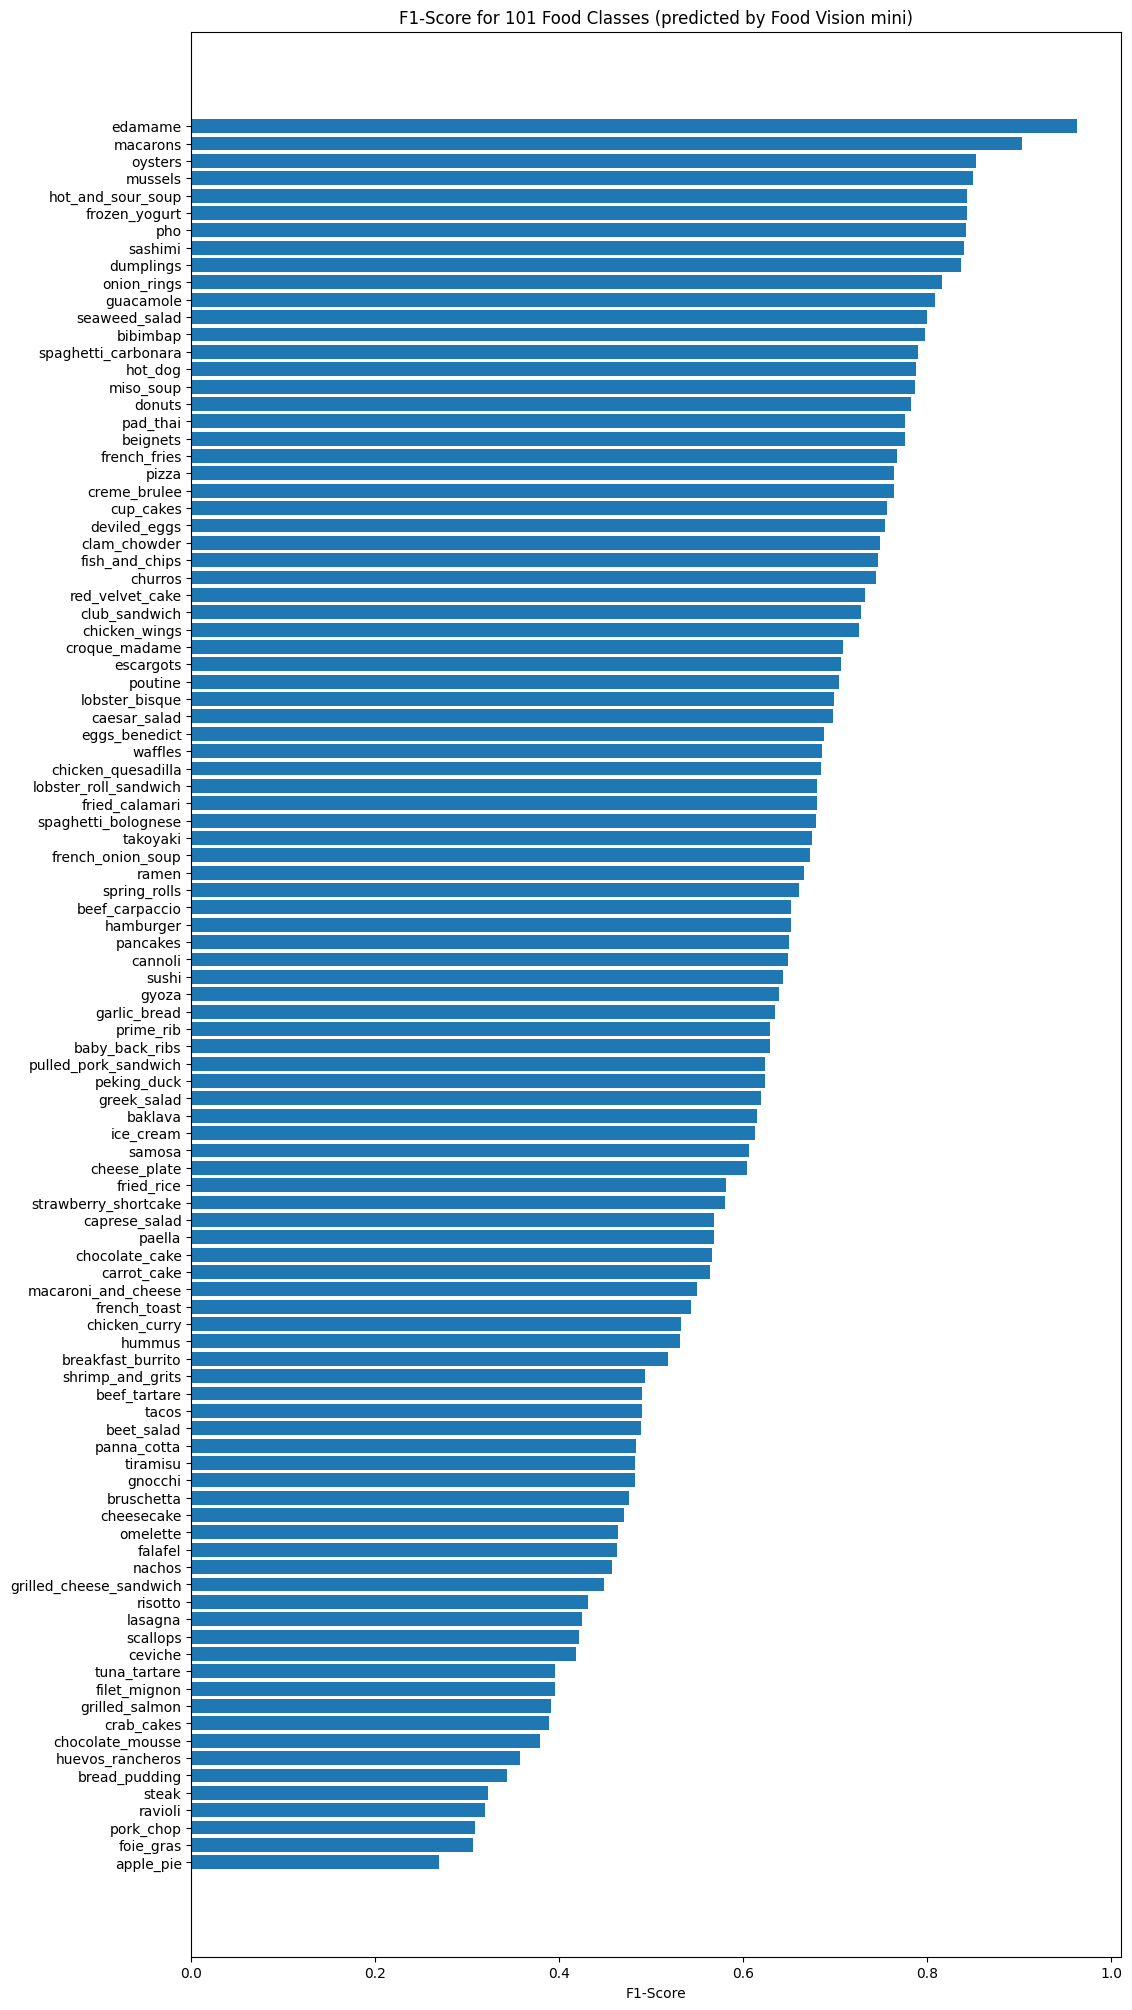

In [44]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(figsize=(12,25))
scores = ax.barh(range(len(f1_scores)),f1_scores["f1-score"].values) # get f1-score values
ax.set_yticks(range(len(f1_scores)))
ax.set_yticklabels(f1_scores["class_names"])
ax.set_xlabel("F1-Score")
ax.set_title("F1-Score for 101 Food Classes (predicted by Food Vision mini)")
ax.invert_yaxis(); # reverse the order of our plot

# Challenge: add values to the end of each bar of what the actual f1-score is
# (hint: use the "autolabel" function from here: https://matplotlib.org/2.0.2/examples/api/barchart_demo.html )

🛠**Exercise:** Try visualizing some of the most poorly predicted classes (e.g. apple_pie, pork_chip), do you notice any trends among them? Why might our modls be having trouble with them?

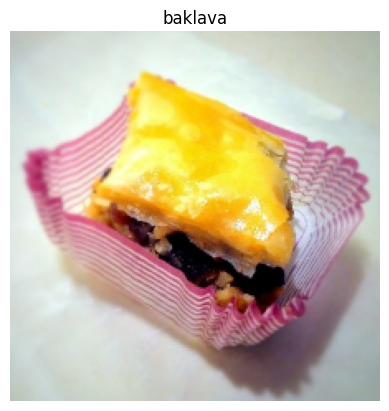

In [46]:
for image, labels in test_data_all.unbatch():
  if labels.numpy().argmax() == 2:
    plt.imshow(image/255.0) #normalize
    # plt.imshow(image.astype("uint8"))
    plt.title(class_names[labels.numpy().argmax()])
    plt.axis(False)
    break

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_poor_predictions_stream(dataset, model, class_names, worst_classes, max_images=5):

    shown = 0

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        pred_classes = np.argmax(preds, axis=1)

        for i in range(len(images)):
            true_class = class_names[int(labels[i])]
            pred_class = class_names[pred_classes[i]]

            if true_class in worst_classes and true_class != pred_class:

                plt.figure()
                plt.imshow(images[i])
                plt.title(f"True: {true_class}\nPred: {pred_class}")
                plt.axis("off")
                plt.show()

                shown += 1
                if shown >= max_images:
                    return

In [ ]:
worst_classes = sorted(class_f1_scores, key=class_f1_scores.get)[:5]

visualize_poor_predictions_stream(
    test_data_all,
    loaded_model,
    test_data_all.class_names,
    worst_classes
)

<h1 style="color:red">lec 017:-Creating a function to load and prepare images for making predictions</h1>

## Visualizing predictions on test images

Now, this is the real test, how does our model go on food images not even in our test dataset (images of our own).

To visualize our model's predictions on our own images, we'll need a function to load and preprocess images, specifically it will need to:
* Read in a target image file path using tf.io.read_file()
* Turn the image into a Tensor using tf.io.decode_image()
* Resize the image tensor to be the same size as the images our model has trained on using tf.image.resize()
* Scale the image to get all of the pixel value between 0 & 1 (if necessary)


In [ ]:
# Create a function to load and prepare images
def load_and_prep_image(filename, img_shape=224, scale = True):
  """
  Reads in an image from filename, turns it into a tensor and reshapes
  into specified shape (img_shape, img_shape, color_channels=3).

  Args:
    filename (str): path to target image
    image_shape (int): height/width dimesnsion of target image size
    scale (bool): scale pixel values from 0-255 to 0-1 or not

  Returns:
    Image tensor of shape (img_shape, img_shape, 3)
  """
  # Read in the image
  img = tf.io.read_file(filename)

  # Decode image into tensor
  img = tf.io.decode_image(img, channels = 3)

  # Resize the image
  img = tf.image.resize(img, [img_shape,img_shape])

  # Scale? Yes/No
  if scale:
    # rescale the image (get all values between 0 and 1)
    return img/255.
  else:
    return img # don't need to rescale images for EfficientNet models in TensorFlow

<h1 style="color:red">lec 018:-Making predictions on our test images and evaluating them.mp4</h1>

Now we've got a function to load and prepare target images, let's now write some code to visualize images, their target label and our model's predictions.

Specifically, we'll write some code to:
1. Load a few random imaged from the test dataset
2. Make predictions on the loaded images
3. Plot the original image(s) along with the model's predictions, prediction probability and the truth label

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


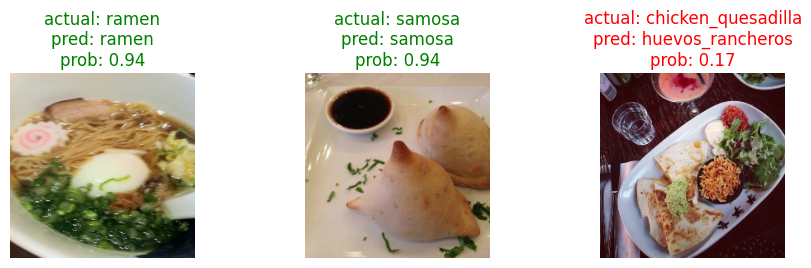

In [49]:
# Make preds on series of random images
import os
import random

plt.figure(figsize=(10,30))
for i in range(3):
  # Choose random image(s) from a random class(es)
  class_name = random.choice(class_names)
  filename = random.choice(os.listdir(test_dir+"/"+class_name))
  filepath = test_dir+"/"+class_name+"/"+filename

  # Load the image and make predictions
  img = load_and_prep_image(filepath,scale=False)
  # first match the img dimension with batch and then predict
  pred_prob = loaded_model.predict(tf.expand_dims(img,axis=0)) # get prediction probabilities array
  pred_class = class_names[pred_prob.argmax()] # get highest prediction probability index

  # Plot the image(s)
  plt.subplot(1,3,i+1)
  plt.imshow(img/255.)
  if class_name == pred_class: # if predicted class matches truth class, make text green
    title_color = "g"
  else:
    title_color = "r"
  plt.title(f"actual: {class_name}\npred: {pred_class}\nprob: {pred_prob.max():.2f}", c= title_color)
  plt.axis(False);
plt.subplots_adjust(wspace=0.6)   # KEY FIX

In [40]:
test_dir

'101_food_classes_10_percent/test'

<h1 style="color:red">lec 019:-Discussing the benefits of finding your model's most wrong predictions</h1>

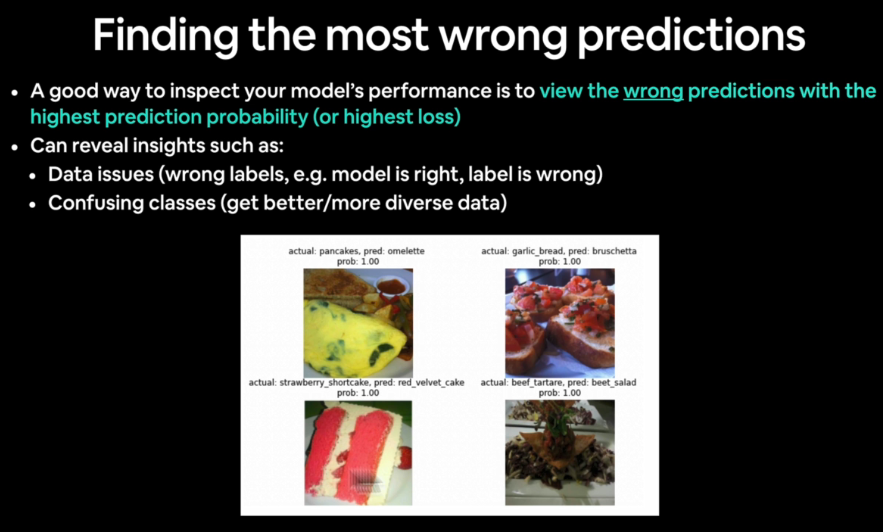

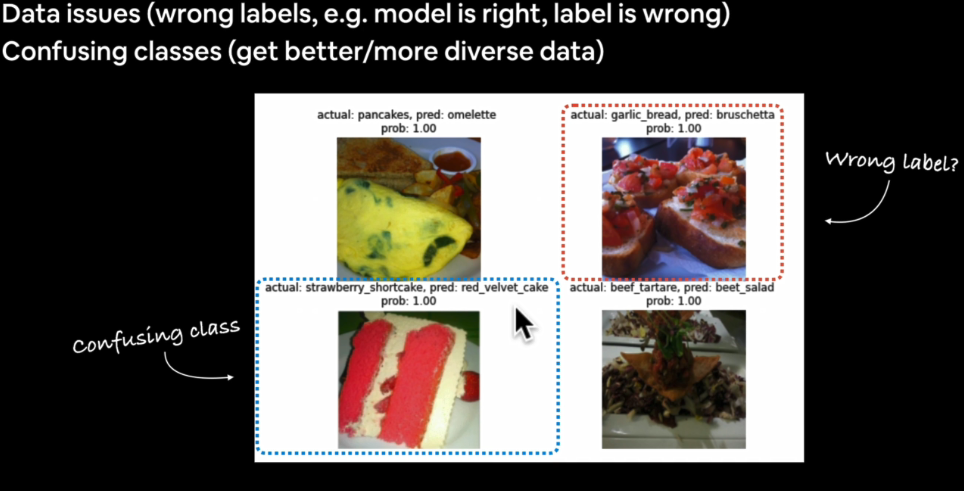

## Finding the most wrong predictions

To find out where our model is most wrong, let's write some code to find out the following:
1. Get all of the image file paths in the test dataset using list_files() method
2. Create a pandas DataFrame of the image filepaths, ground truth labels, predicted classes (from our model), max prediction probabilities.
3. Use ouir DataFrame to find all the wrong predictions (where the ground truth label doesn't match the prediction).
4. Sort the DataFrame based on wrong predictions (have the highest prediction probability predictions at the top).
5. Visualize the images with the highest prediction probabilities but have the wrong prediction.

<h1 style="color:red">lec 020:-Writing code to uncover our model's most wrong predictions</h1>

In [ ]:
# 1. Get all of the image file paths in the test dataset
filepaths = []
for filepath in test_data_all.list_files(test_dir+"/*/*.jpg",
                                         shuffle=False):
  filepaths.append(filepath.numpy())
filepaths[:10]

In [ ]:
# 2. Create a DataFrame of different parameters for each of our test images
import pandas as pd
pred_df = pd.DataFrame({"img_path": filepaths,
                        "y_true": y_labels,
                        "y_pred": pred_classes,
                        "pred_conf": pred_probs.max(axis=1),
                        "y_true_classnames":[class_names[i] for i in y_labels],
                        "y_pred_classnames":[class_names[i] for i in pred_classes]})

pred_df

In [ ]:
# 3. Find out in our DataFrame which predictions are wrong
pred_df["pred_correct"] = pred_df["y_true"] == pred_df["y_pred"]
pred_df.head()

In [ ]:
# 4. Sort our DataFrame to have most wrong predictions at the top
top_100_wrong = pred_df[pred_df["pred_correct"]==False].sort_values("pred_conf",ascending=False)[:100]
top_100_wrong.head(20)

<h1 style="color:red">lec 021:-Plotting and visualising the samples our model got most wrong</h1>

In [ ]:
# 5. Visualize the test data samples which have the wrong predcition but highest pred probability
image_to_view = 9
start_index =10
plt.figure(figsize=(15,10))
for i, row in enumerate(top_100_wrong[start_index:start_index+images_to_view].itertuples()):
  plt.subplots(3,3,i+1)
  img = load_and_prep_image(row[1],scale=False)
  _, _,_,_, pred_prob, y_true_classname, y_pred_classname, _ = row # only interested in few parameters of each row
  plt.imshow(img/255.0)
  plt.title(f"actual: {y_true_classname}\npred: {y_pred_classname}\nprob: {pred_prob}")
  plt.axis(False)



<h1 style="color:red">lec 022:-Making predictions on and plotting our own custom images</h1>

## Test out the big dog model on our own custom images

In [ ]:
# Get custom images
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/custom_food_images.zip

In [ ]:
unzip_data("custom_food_images.zip")

In [ ]:
# Get the custom food images filepaths
custom_food_images_paths = ["custom_food_images/"+img_path for img_path in os.listdir("custom_food_images")]
custom_food_images

In [ ]:
# Make predictions on and plot custom food images
for img in custom_food_images:
  img = load_and_prep_image(img,scale=False) # don't need to scale for our EfficientNetB0 model
  pred_prob= loaded_model.predict(tf.expand_dims(img,axis=0)) # make prediction on image with shaoe [1,224,224,3]
  pred_class = class_names[pred_prob.argmax()] # get the index with the highest predicion probability

  # Plot the appropriate information
  plt.figure()
  plt.imshow(img/255.0)
  plt.title(f"pred: {pred_class}\nprob: {pred_prob.max():.2f}")
  plt.axis(False)

<body>
                <div class="container">
                <div class="row">
                <div class="col-md-10 col-md-offset-1">
                    <p class="lead"><p>Yes! Massive effort!</p><p>You just went through a bunch of incredibly helpful steps for evaluating a model's performance.</p><p>In particular, finding out where a model's predictions are the <em>most</em> wrong.</p><p>And once again, you lived up to the machine learning practitioner's motto!</p><p>“Experiment, experiment, experiment!”</p><p>You should now be able to:</p><ul><li><p>Discover your model's performance per class</p></li><li><p>Evaluate your model's most wrong predictions (by visualizing the samples where a model's prediction probability is high but the output label is wrong)</p></li><li><p>Make predictions on your own custom images/data with a trained model</p></li></ul><p>As always, it's time to practice your new skills.</p><p>In the <a href="https://github.com/mrdbourke/tensorflow-deep-learning" rel="noopener noreferrer" target="_blank">course GitHub repo</a> under “Course materials”, you'll find a series of exercises and extra-curriculum suggestions.</p><p>You should go through these <strong>before</strong> moving on to the next section.</p><p>See the link below for more.</p><ul><li><p><a href="https://github.com/mrdbourke/tensorflow-deep-learning#-06-transfer-learning-in-tensorflow-part-3-scaling-up-exercises" rel="noopener noreferrer" target="_blank">Transfer Learning in TensorFlow Part 3: Scaling up</a></p></li></ul><p>And remember, if you have any questions, be sure to <a href="https://github.com/mrdbourke/tensorflow-deep-learning/discussions" rel="noopener noreferrer" target="_blank">add them to the discussions page</a>.</p><p><strong>Challenge:</strong> Make predictions with your model on 3 of your own photos of food from the Food101 classes and plot the model's predictions, prediction probability and true label (you'll provide this). Make the plot title red if the model gets it wrong and green if it gets it right.</p><p>Send a message with your results to the #machinelearning-datascience channel on Discord and mention my name (@mrdbourke), I’d love to see what happens!</p><p>See you in the next module!</p><p>- Daniel</p><p>Web: <a href="http://www.mrdbourke.com/" rel="noopener noreferrer" target="_blank">www.mrdbourke.com</a></p><p>YouTube: <a href="https://dbourke.link/youtube" rel="noopener noreferrer" target="_blank">https://dbourke.link/youtube</a></p></p>
                </div>
                </div>
                </div>
                <script src="https://maxcdn.bootstrapcdn.com/bootstrap/3.3.7/js/bootstrap.min.js" integrity="sha384-Tc5IQib027qvyjSMfHjOMaLkfuWVxZxUPnCJA7l2mCWNIpG9mGCD8wGNIcPD7Txa" crossorigin="anonymous"></script>
                </body>